In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Define what we need from the table
metrics = ['SARI', 'COMET', 'LENS', 'MAE']
datasets = ['Med-EASi', 'SimPA']  # M and S in the table
control_attrs = ['FKGL', 'Char Compression']

# Hardcode the actual model names from JSON
models = {
    'Llama': ['Llama-3.2-1B-Instruct', 'Llama-3.2-3B-Instruct', 'Llama-3.1-8B-Instruct', 'Llama-2-13b-chat-hf'],
    'Qwen': ['Qwen3-1.7B', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B']
}
    
print("Models:", models)
print("Control Attributes:", control_attrs)
print("Datasets:", datasets)
print("Metrics:", metrics)

Models: {'Llama': ['Llama-3.2-1B-Instruct', 'Llama-3.2-3B-Instruct', 'Llama-3.1-8B-Instruct', 'Llama-2-13b-chat-hf'], 'Qwen': ['Qwen3-1.7B', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B']}
Control Attributes: ['FKGL', 'Char Compression']
Datasets: ['Med-EASi', 'SimPA']
Metrics: ['SARI', 'COMET', 'LENS', 'MAE']


In [3]:
# Load the JSON file
import json

with open('./../output/sft_results/all_results.json', 'r') as f:
    data = json.load(f)

In [4]:

results = {metric: {attr: {ds: {family: [] for family in ['Llama', 'Qwen']} 
                            for ds in datasets} 
                    for attr in control_attrs} 
           for metric in ['SARI', 'COMET', 'MAE']}

for family, model_list in models.items():
    for idx, model_name in enumerate(model_list):
        if model_name not in data:
            print(f"Warning: {model_name} not found in data")
            continue
        
        # Extract for each dataset and control attribute
        for ds in datasets:
            if ds not in data[model_name]:
                print(f"Warning: {ds} not found for {model_name}")
                continue
                
            for attr in control_attrs:
                # The JSON has different naming - check both
                attr_key = 'CHAR_COMPRESSION' if attr == 'Char Compression' else attr
                
                if attr_key not in data[model_name][ds]:
                    print(f"Warning: {attr_key} not found for {model_name}/{ds}")
                    continue
                
                attr_data = data[model_name][ds][attr_key]
                
                # Extract SARI and COMET from mean_metrics
                if 'mean_metrics' in attr_data:
                    if 'SARI' in attr_data['mean_metrics']:
                        while len(results['SARI'][attr][ds][family]) <= idx:
                            results['SARI'][attr][ds][family].append(0)
                        results['SARI'][attr][ds][family][idx] = attr_data['mean_metrics']['SARI']['mean']
                    
                    if 'COMET' in attr_data['mean_metrics']:
                        while len(results['COMET'][attr][ds][family]) <= idx:
                            results['COMET'][attr][ds][family].append(0)
                        results['COMET'][attr][ds][family][idx] = attr_data['mean_metrics']['COMET']['mean']
                
                # Extract MAE from losses
                if 'losses' in attr_data and 'MAE' in attr_data['losses']:
                    while len(results['MAE'][attr][ds][family]) <= idx:
                        results['MAE'][attr][ds][family].append(0)
                    results['MAE'][attr][ds][family][idx] = attr_data['losses']['MAE']


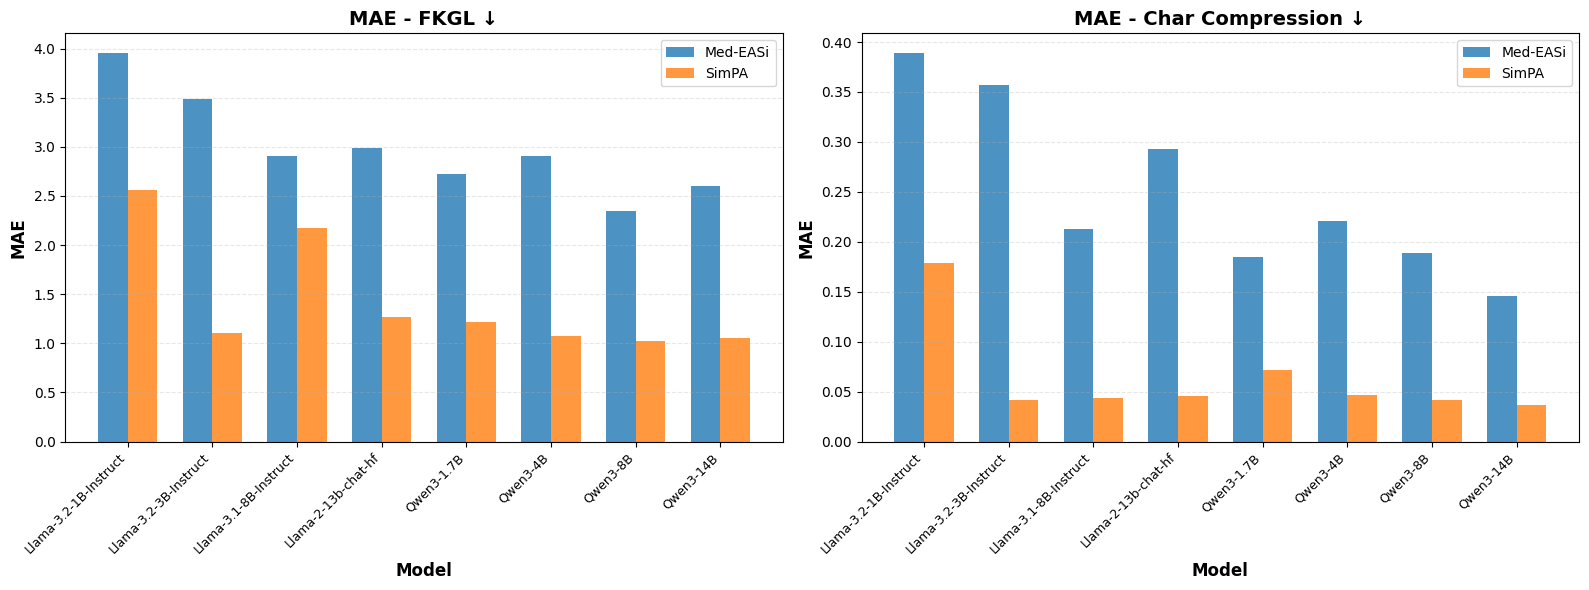

In [5]:
# Create 2 side-by-side plots for MAE only
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bar_width = 0.35
x_positions = np.arange(8)  # 4 Llama + 4 Qwen models

for idx, attr in enumerate(control_attrs):
    ax = axes[idx]
    offset = -0.5 * bar_width
    
    # Plot each dataset
    for ds in datasets:
        values = results['MAE'][attr][ds]['Llama'] + results['MAE'][attr][ds]['Qwen']
        ax.bar(x_positions + offset, values, bar_width, label=ds, alpha=0.8)
        offset += bar_width
    
    # Formatting
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('MAE', fontsize=12, fontweight='bold')
    ax.set_title(f'MAE - {attr} ↓', fontsize=14, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(models['Llama'] + models['Qwen'], 
                        rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('./../visualizations/mae_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Rows collected: 76
Missing/partial entries (first 12 shown):
   ('Mistral 3B | SimPA | FKGL', True, False)
   ('Mistral 3B | SimPA | CHAR_COMPRESSION', True, False)
   ('Mistral 3B | WikiLarge_ori_splitwise | FKGL', True, False)
   ('Mistral 3B | WikiLarge_ori_splitwise | CHAR_COMPRESSION', True, False)
   ('Mistral 3B | Newsela_s | FKGL', True, False)
   ('Mistral 3B | Newsela_s | CHAR_COMPRESSION', True, False)
   ('Mistral 7B', 'Mistral-7B-Instruct-v0.1', None)
   ('Qwen 1.7B | SimPA | FKGL', True, False)
   ('Qwen 1.7B | SimPA | CHAR_COMPRESSION', True, False)
   ('Qwen 1.7B | WikiLarge_ori_splitwise | FKGL', True, False)
   ('Qwen 1.7B | WikiLarge_ori_splitwise | CHAR_COMPRESSION', True, False)
   ('Qwen 1.7B | Newsela_s | FKGL', True, False)

Delta-only charts (one figure per dataset):
  x-axis: model name
  y-axis: delta vs baseline (positive = SFT better)


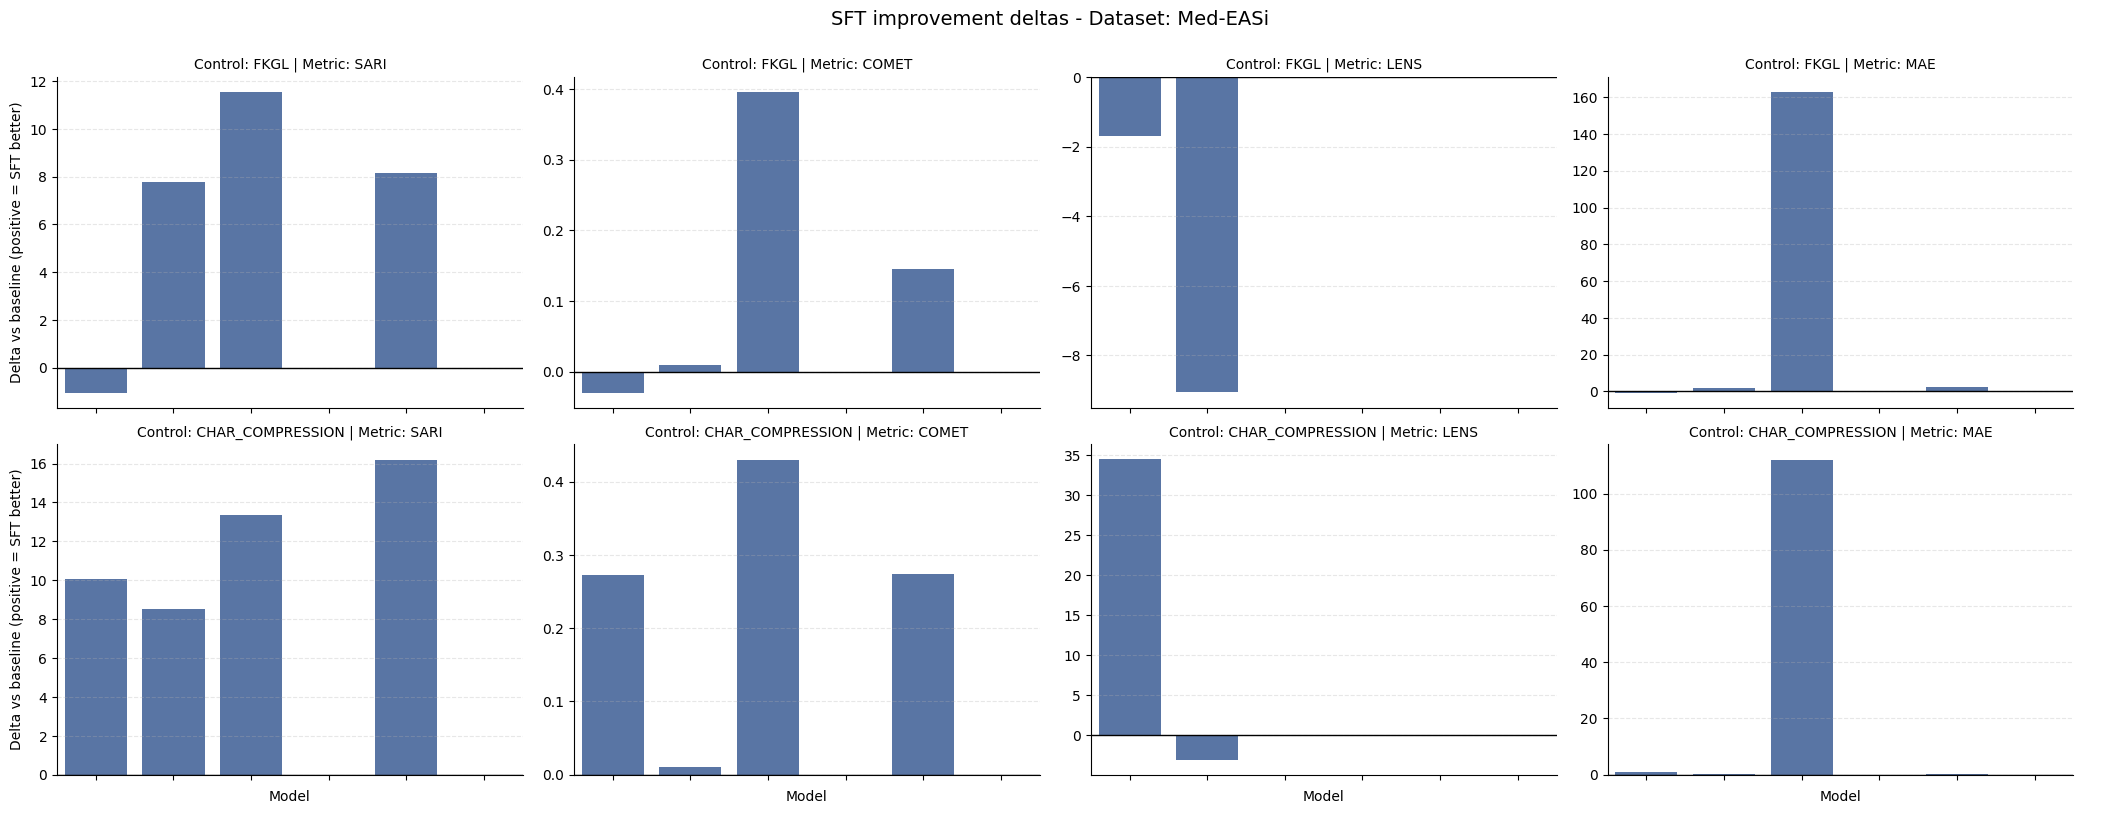

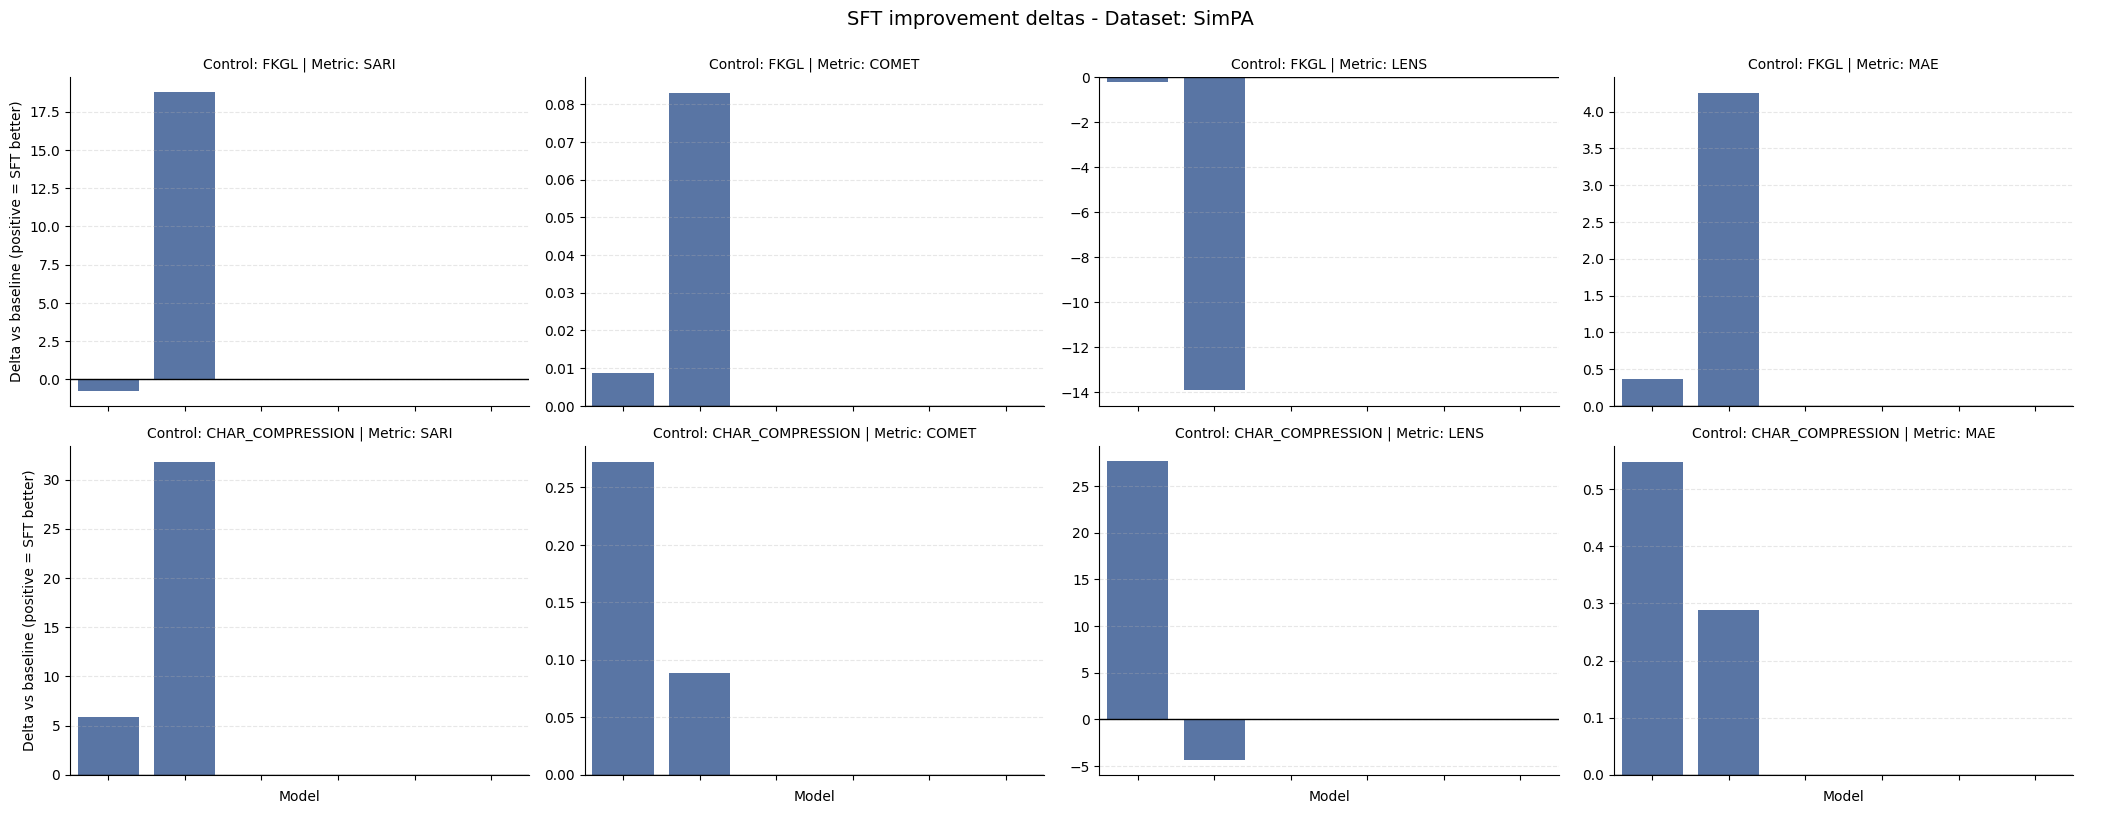

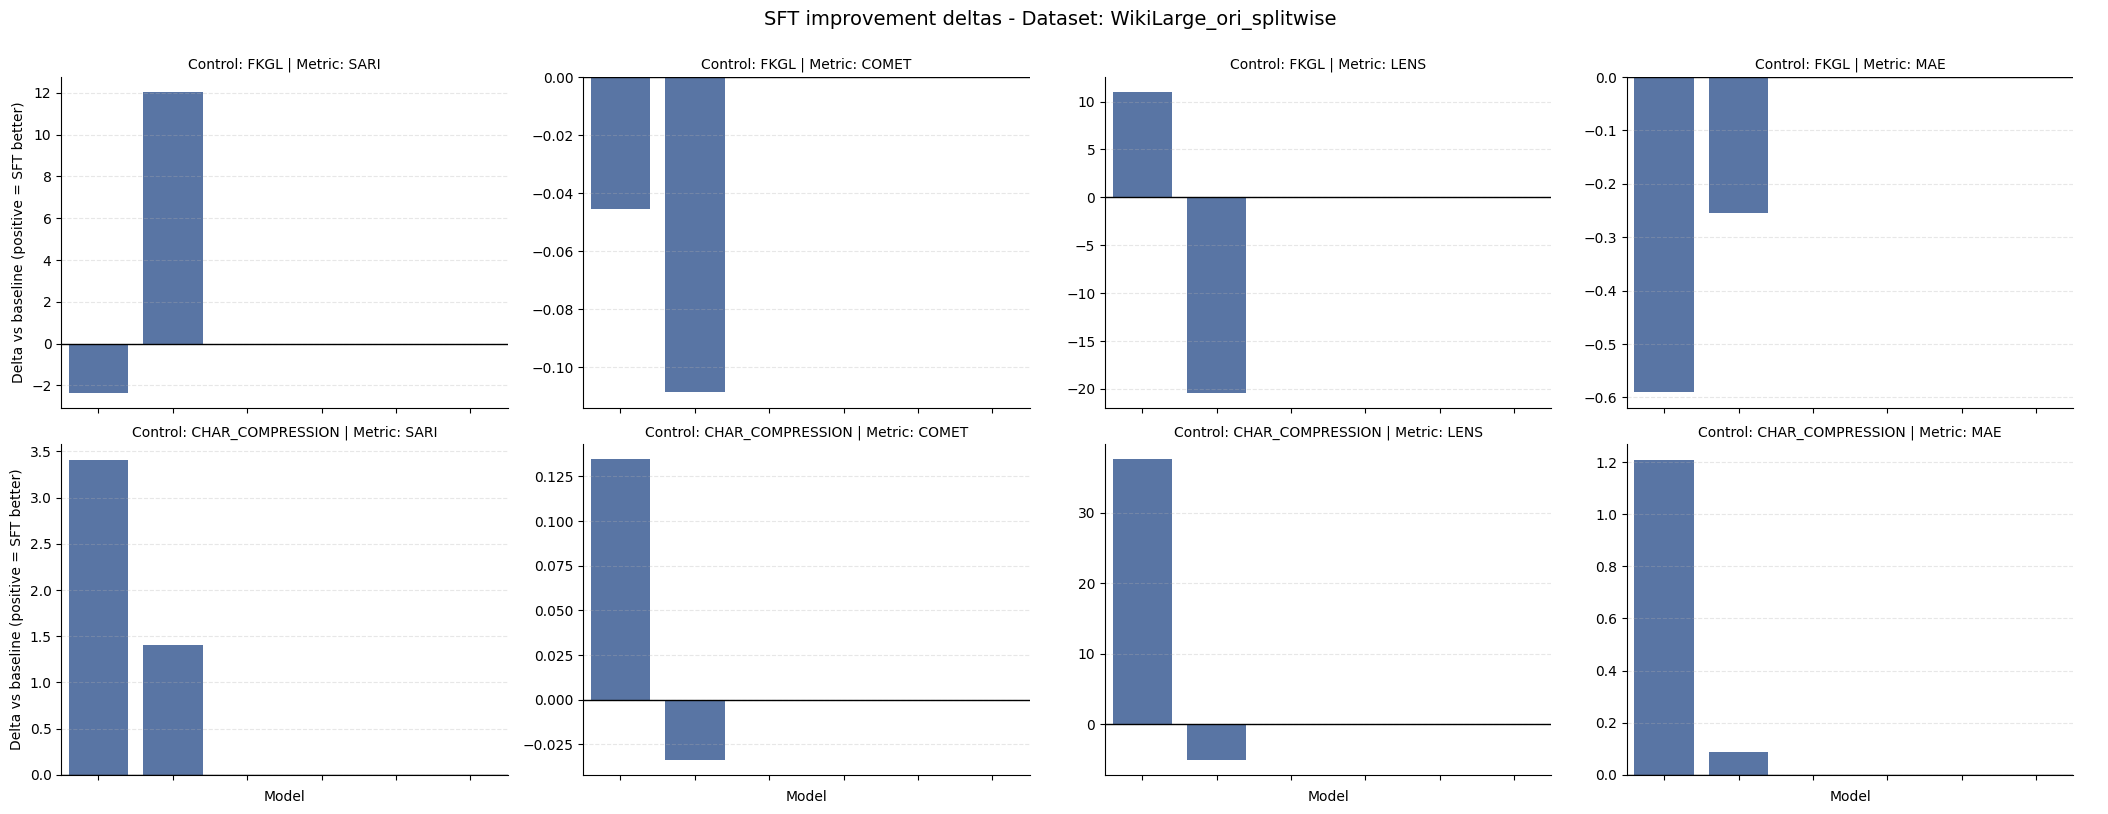

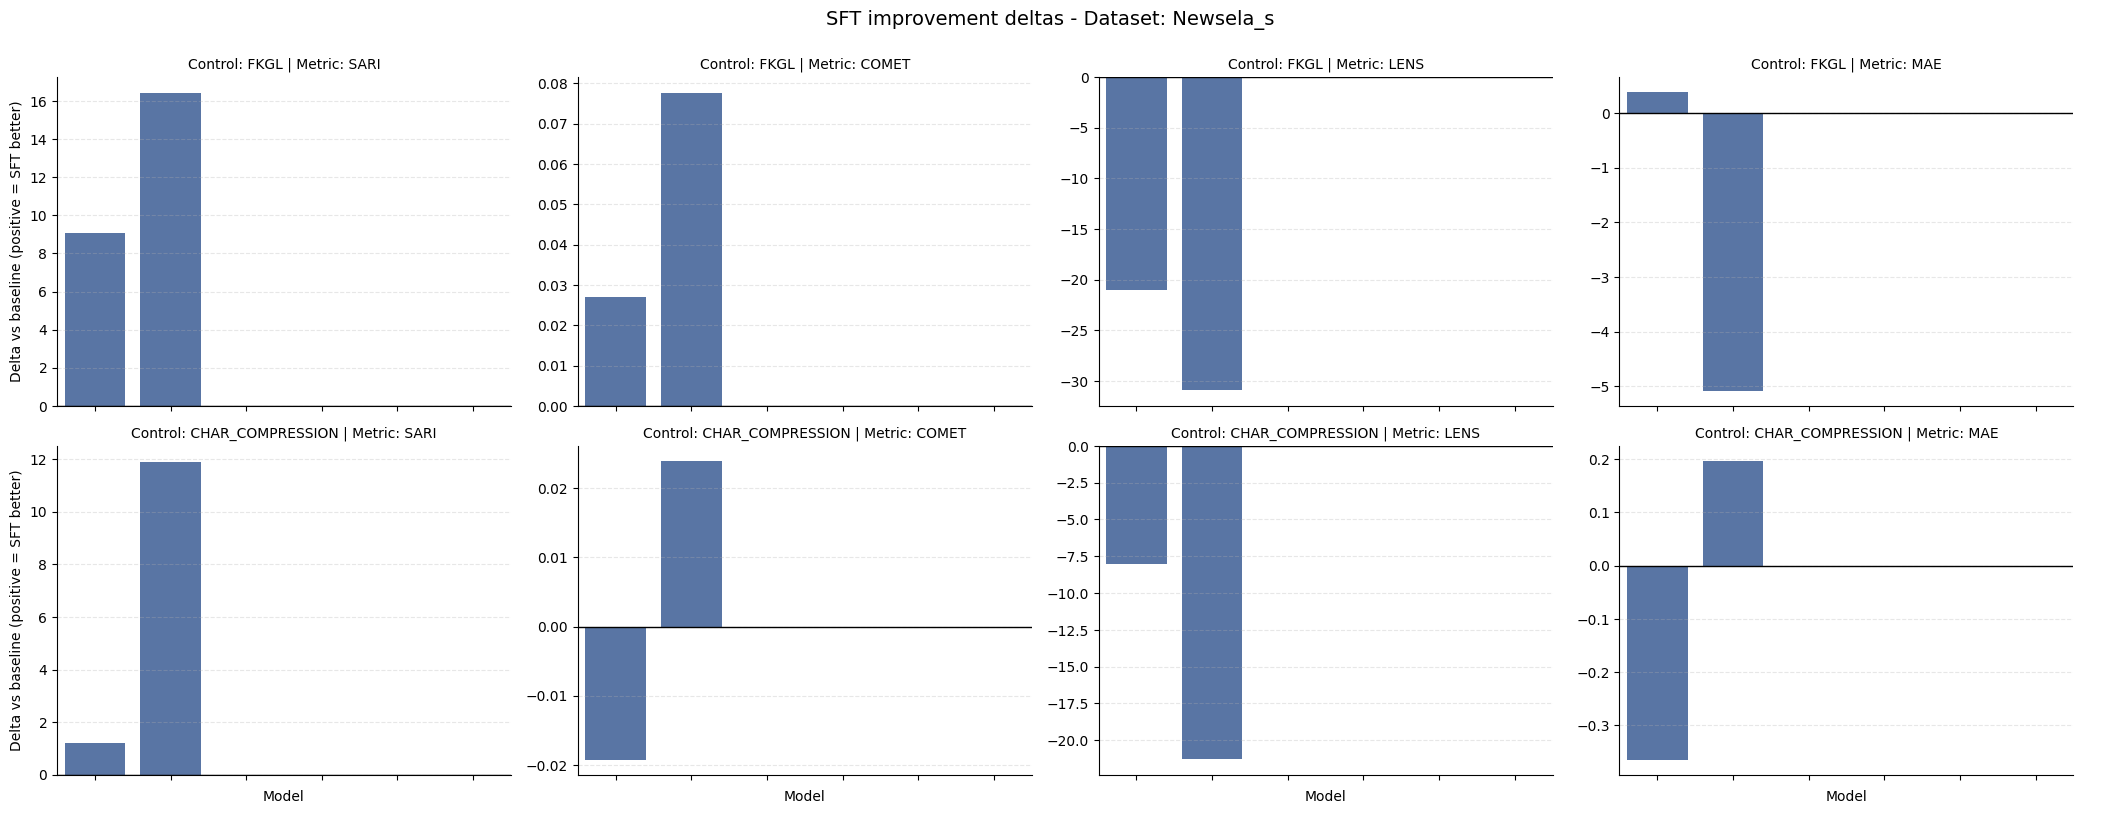


Average improvement by dataset/control/metric/model (higher is better):


,dataset,control_attr,metric,model,delta_improvement
2,Med-EASi,CHAR_COMPRESSION,COMET,Mistral 3B,0.429540
4,Med-EASi,CHAR_COMPRESSION,COMET,Qwen 1.7B,0.274201
0,Med-EASi,CHAR_COMPRESSION,COMET,Llama 1B,0.272033
1,Med-EASi,CHAR_COMPRESSION,COMET,Llama 8B,0.009975
3,Med-EASi,CHAR_COMPRESSION,COMET,Mistral 7B,NaN
...,...,...,...,...,...
75,Newsela_s,FKGL,COMET,Mistral 7B,NaN
76,Newsela_s,FKGL,COMET,Qwen 1.7B,NaN
77,Newsela_s,FKGL,COMET,Qwen 8B,NaN
78,Newsela_s,FKGL,LENS,Llama 1B,-21.024846


In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Paths ----------
sft_summary_path = './../output/sft_results/all_results.json'
baseline_summary_path = './../output/nonsft_results_baseline/all_results.json'

with open(sft_summary_path, 'r', encoding='utf-8') as f:
    sft_results = json.load(f)

with open(baseline_summary_path, 'r', encoding='utf-8') as f:
    baseline_results = json.load(f)

# ---------- Scope requested ----------
target_datasets = ['Med-EASi', 'SimPA', 'WikiLarge_ori_splitwise', 'Newsela_s']
target_control_attrs = ['FKGL', 'CHAR_COMPRESSION']
target_metrics = ['SARI', 'COMET', 'LENS', 'MAE']

# Core models requested by user (aliases for robust matching)
core_model_aliases = {
    'Llama 1B': ['Llama-3.2-1B-Instruct'],
    'Llama 8B': ['Llama-3.1-8B-Instruct', 'Meta-Llama-3.1-8B-Instruct'],
    'Mistral 3B': ['Ministral-3b-instruct', 'ministral/Ministral-3b-instruct'],
    'Mistral 7B': ['Mistral-7B-Instruct-v0.1', 'mistralai/Mistral-7B-Instruct-v0.1'],
    'Qwen 1.7B': ['Qwen3-1.7B', 'Qwen/Qwen3-1.7B'],
    'Qwen 8B': ['Qwen3-8B', 'Qwen/Qwen3-8B'],
}

def find_model_key(results_dict, aliases):
    keys = list(results_dict.keys())
    lower_map = {k.lower(): k for k in keys}
    for alias in aliases:
        a = alias.lower()
        if a in lower_map:
            return lower_map[a]
        # relaxed contains match in either direction
        for k in keys:
            lk = k.lower()
            if a in lk or lk in a:
                return k
    return None

def get_metric_value(entry, metric):
    if metric == 'MAE':
        return entry.get('losses', {}).get('MAE', np.nan)
    return entry.get('mean_metrics', {}).get(metric, {}).get('mean', np.nan)

rows = []
missing = []

for pretty_name, aliases in core_model_aliases.items():
    sft_model_key = find_model_key(sft_results, aliases)
    base_model_key = find_model_key(baseline_results, aliases)

    if sft_model_key is None or base_model_key is None:
        missing.append((pretty_name, sft_model_key, base_model_key))
        continue

    for ds in target_datasets:
        for ctrl in target_control_attrs:
            sft_entry = sft_results.get(sft_model_key, {}).get(ds, {}).get(ctrl, {})
            base_entry = baseline_results.get(base_model_key, {}).get(ds, {}).get(ctrl, {})

            if not sft_entry or not base_entry:
                missing.append((f'{pretty_name} | {ds} | {ctrl}', bool(sft_entry), bool(base_entry)))
                continue

            for metric in target_metrics:
                base_val = get_metric_value(base_entry, metric)
                sft_val = get_metric_value(sft_entry, metric)

                if pd.isna(base_val) or pd.isna(sft_val):
                    continue

                # Positive delta always means SFT improved.
                if metric == 'MAE':
                    delta = base_val - sft_val  # lower MAE is better
                else:
                    delta = sft_val - base_val  # higher metric is better

                rows.append({
                    'model': pretty_name,
                    'dataset': ds,
                    'control_attr': ctrl,
                    'metric': metric,
                    'baseline': float(base_val),
                    'sft': float(sft_val),
                    'delta_improvement': float(delta),
                })

comparison_df = pd.DataFrame(rows)
print(f'Rows collected: {len(comparison_df)}')
if missing:
    print('Missing/partial entries (first 12 shown):')
    for m in missing[:12]:
        print('  ', m)

if comparison_df.empty:
    raise ValueError('No overlapping baseline/SFT entries found for requested models/settings.')

model_order = list(core_model_aliases.keys())
comparison_df['model'] = pd.Categorical(
    comparison_df['model'],
    categories=model_order,
    ordered=True,
)

print('\nDelta-only charts (one figure per dataset):')
print('  x-axis: model name')
print('  y-axis: delta vs baseline (positive = SFT better)')

for ds in target_datasets:
    ds_df = comparison_df[comparison_df['dataset'] == ds].copy()

    if ds_df.empty:
        print(f'Skipping {ds}: no data available.')
        continue

    g = sns.catplot(
        data=ds_df,
        x='model', y='delta_improvement',
        col='metric', row='control_attr',
        kind='bar',
        height=4.2, aspect=1.25,
        sharey=False,
        color='#4C72B0'
    )

    g.set_xticklabels(rotation=25, ha='right')
    g.set_axis_labels('Model', 'Delta vs baseline (positive = SFT better)')
    g.set_titles(row_template='Control: {row_name}', col_template='Metric: {col_name}')

    for ax in g.axes.flat:
        ax.axhline(0.0, color='black', linewidth=1)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f'SFT improvement deltas - Dataset: {ds}', fontsize=14)
    plt.show()

# ---------- Quick diagnostic table ----------
summary = (
    comparison_df
    .groupby(['dataset', 'control_attr', 'metric', 'model'], as_index=False)['delta_improvement']
    .mean()
    .sort_values(['dataset', 'control_attr', 'metric', 'delta_improvement'], ascending=[True, True, True, False])
)

print('\nAverage improvement by dataset/control/metric/model (higher is better):')
display(summary.head(80))